# Empirical vs Analytical compositional Analysis (OPTION A - CORRECTED)

**Purpose:** Demonstrates the corrected Option A probabilistic combination method

**Status:** CORRECTED method. Compare with notebook 11.1 (old broken method).

**Formula (CORRECTED):**
```
P(compound→pathway) = 1 - ∏_gene (1 - P(compound→gene) × P(gene→pathway))
```

Treats multiple pathways as independent alternative routes, ensuring all probabilities ≤ 1.0.

**Reference:** Himmelstein et al. (2017) eLife. https://doi.org/10.7554/eLife.26726

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
from scipy.stats import pearsonr, spearmanr
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Setup paths
repo_dir = Path.cwd().parent
src_dir = repo_dir / 'src'
data_dir = repo_dir / 'data'
results_dir = repo_dir / 'results'

sys.path.append(str(src_dir))

print(f"Repository: {repo_dir}")

# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

Repository: /Users/lucas/Library/CloudStorage/OneDrive-TheUniversityofColoradoDenver/Repositories/Context-Aware-Path-Probability


## Configuration

In [2]:
# Test metapath: CbGpPW
metapath = ['CbG', 'GpPW']
metapath_name = 'CbGpPW'

# Analyze only Hetionet for demonstration
HETIONET_ID = 0

# Degree bins for stratification
DEGREE_BINS = [0, 5, 20, 100, np.inf]
DEGREE_LABELS = ['Very Low (0-5)', 'Low (5-20)', 'Medium (20-100)', 'High (>100)']

print(f"Testing metapath: {metapath_name}")
print(f"  Edge 1: {metapath[0]} (Compound → Gene)")
print(f"  Edge 2: {metapath[1]} (Gene → Pathway)")
print(f"\nAnalyzing Hetionet with CORRECTED OPTION A METHOD")
print(f"Hetionet (real): {HETIONET_ID:03d}")

Testing metapath: CbGpPW
  Edge 1: CbG (Compound → Gene)
  Edge 2: GpPW (Gene → Pathway)

Analyzing Hetionet with CORRECTED OPTION A METHOD
Hetionet (real): 000


## Helper Functions

In [3]:
def load_edge_matrix(edge_type: str, perm_id: int = 0) -> sp.csr_matrix:
    """Load edge matrix for given edge type and permutation."""
    edge_file = data_dir / 'permutations' / f'{perm_id:03d}.hetmat' / 'edges' / f'{edge_type}.sparse.npz'
    return sp.load_npz(edge_file)

def bin_degrees(df: pd.DataFrame, bins=DEGREE_BINS, labels=DEGREE_LABELS):
    """Add degree bin columns to DataFrame."""
    ordered_categories = pd.CategoricalDtype(categories=labels, ordered=True)

    df['compound_degree_bin'] = pd.cut(df['compound_degree'], bins=bins, labels=labels)
    df['compound_degree_bin'] = df['compound_degree_bin'].astype(ordered_categories)

    df['pathway_degree_bin'] = pd.cut(df['pathway_degree'], bins=bins, labels=labels)
    df['pathway_degree_bin'] = df['pathway_degree_bin'].astype(ordered_categories)

    return df

## Option A Probabilistic Combination (CORRECTED)

This function uses the corrected formula that guarantees all probabilities ≤ 1.0.

In [ ]:
def compute_metapath_compositionality(edge1_matrix, edge2_matrix, perm_id):
    """
    Compute compositionality using Option A probabilistic combination (CORRECTED).

    Formula: P(compound→pathway) = 1 - ∏_gene (1 - P(compound→gene) × P(gene→pathway))

    This ensures all probabilities remain ≤ 1.0.
    Compare with notebook 11.1 (old broken summation method).
    """
    # Align gene dimensions
    assert edge1_matrix.shape[1] == edge2_matrix.shape[0], "Gene dimension mismatch!"

    # Filter zero-degree compounds and pathways
    compound_degrees = np.array(edge1_matrix.sum(axis=1)).flatten()
    pathway_degrees = np.array(edge2_matrix.sum(axis=0)).flatten()

    compound_nonzero = np.where(compound_degrees > 0)[0]
    pathway_nonzero = np.where(pathway_degrees > 0)[0]

    edge1_aligned = edge1_matrix[compound_nonzero, :]
    edge2_aligned = edge2_matrix[:, pathway_nonzero]

    n_compounds = edge1_aligned.shape[0]
    n_pathways = edge2_aligned.shape[1]

    # Compute gene degrees from both edge types for pathway degree products
    gene_degrees_in = np.array(edge1_aligned.sum(axis=0)).flatten()   # From CbG (compounds→genes)
    gene_degrees_out = np.array(edge2_aligned.sum(axis=1)).flatten()  # From GpPW (genes→pathways)

    # Compute metapath matrix
    metapath_matrix = edge1_aligned @ edge2_aligned

    # 1. Compute observed frequencies
    observed_freq = {}
    for i, j in zip(*metapath_matrix.nonzero()):
        compound_genes = edge1_aligned.getrow(i).nonzero()[1]
        pathway_genes = edge2_aligned.getcol(j).nonzero()[0]
        shared_genes = set(compound_genes) & set(pathway_genes)

        n_paths = len(shared_genes)
        n_possible = len(compound_genes)

        if n_possible > 0:
            observed_freq[(i, j)] = n_paths / n_possible

    # 2. Analytical prior formula
    def analytical_prior(u, v, m):
        """Analytical edge probability."""
        uv = u * v
        denominator = np.sqrt(uv**2 + (m - u - v + 1)**2)
        return uv / denominator if denominator > 0 else 0.0

    # Compute edge priors
    edge1_priors = {}
    edge2_priors = {}

    # Edge1 priors
    m1 = edge1_aligned.nnz
    source_degrees = np.array(edge1_aligned.sum(axis=1)).flatten()
    target_degrees = np.array(edge1_aligned.sum(axis=0)).flatten()

    rows, cols = edge1_aligned.nonzero()
    for i, j in zip(rows, cols):
        u, v = source_degrees[i], target_degrees[j]
        if u > 0 and v > 0:
            edge1_priors[(i, j)] = analytical_prior(u, v, m1)

    # Edge2 priors
    m2 = edge2_aligned.nnz
    source_degrees = np.array(edge2_aligned.sum(axis=1)).flatten()
    target_degrees = np.array(edge2_aligned.sum(axis=0)).flatten()

    rows, cols = edge2_aligned.nonzero()
    for i, j in zip(rows, cols):
        u, v = source_degrees[i], target_degrees[j]
        if u > 0 and v > 0:
            edge2_priors[(i, j)] = analytical_prior(u, v, m2)

    # 3. CORRECTED: Option A probabilistic combination with pathway degree products
    compositional_prob = {}
    pathway_degree_products_total = {}
    pathway_degree_products_joint = {}
    prob_over_1_count = 0

    for i in range(n_compounds):
        compound_genes = edge1_aligned.getrow(i).nonzero()[1]

        for j in range(n_pathways):
            pathway_genes = edge2_aligned.getcol(j).nonzero()[0]
            shared_genes = set(compound_genes) & set(pathway_genes)

            if shared_genes:
                # CORRECTED: Probabilistic combination (always ≤ 1.0)
                failure_prob = 1.0

                # Calculate pathway degree products
                pathway_degree_product_total = 1.0  # Product of (in + out)
                pathway_degree_product_joint = 1.0  # Product of (in × out)

                for gene in shared_genes:
                    p_edge1 = edge1_priors.get((i, gene), 0.0)
                    p_edge2 = edge2_priors.get((gene, j), 0.0)
                    individual_prob = p_edge1 * p_edge2
                    failure_prob *= (1 - individual_prob)

                    # Compute gene degree metrics
                    gene_in = gene_degrees_in[gene]
                    gene_out = gene_degrees_out[gene]

                    # Total connectivity: sum of degrees
                    gene_degree_total = gene_in + gene_out
                    pathway_degree_product_total *= gene_degree_total

                    # Joint connectivity: product of degrees (hub measure)
                    gene_degree_joint = gene_in * gene_out
                    pathway_degree_product_joint *= gene_degree_joint

                total_prob = 1 - failure_prob

                if total_prob > 1.0:
                    prob_over_1_count += 1

                if total_prob > 0:
                    compositional_prob[(i, j)] = total_prob
                    pathway_degree_products_total[(i, j)] = pathway_degree_product_total
                    pathway_degree_products_joint[(i, j)] = pathway_degree_product_joint

    if prob_over_1_count > 0:
        print(f"WARNING: {prob_over_1_count} probabilities > 1.0 (unexpected!)")

    # 4. Compute PMI and create results
    results_data = []
    common_pairs = set(observed_freq.keys()) & set(compositional_prob.keys())

    for pair in common_pairs:
        i, j = pair
        p_observed = observed_freq[pair]
        p_compositional = compositional_prob[pair]

        if p_observed > 0 and p_compositional > 0:
            pmi = np.log2(p_observed / p_compositional)
        else:
            pmi = np.nan

        orig_compound_idx = compound_nonzero[i]
        orig_pathway_idx = pathway_nonzero[j]

        compound_degree = compound_degrees[orig_compound_idx]
        pathway_degree = pathway_degrees[orig_pathway_idx]

        results_data.append({
            'perm_id': perm_id,
            'compound_idx': orig_compound_idx,
            'pathway_idx': orig_pathway_idx,
            'compound_degree': int(compound_degree),
            'pathway_degree': int(pathway_degree),
            'pathway_degree_product_total': float(pathway_degree_products_total[pair]),
            'pathway_degree_product_joint': float(pathway_degree_products_joint[pair]),
            'observed_freq': p_observed,
            'compositional_prob': p_compositional,
            'pmi': pmi,
            'residual': p_observed - p_compositional
        })

    return pd.DataFrame(results_data)

## Run Analysis with Corrected Method

In [ ]:
print("Analyzing Hetionet with CORRECTED OPTION A METHOD...\n")

edge1_het = load_edge_matrix(metapath[0], HETIONET_ID)
edge2_het = load_edge_matrix(metapath[1], HETIONET_ID)

print(f"Loaded edge matrices:")
print(f"  {metapath[0]}: {edge1_het.shape} with {edge1_het.nnz} edges")
print(f"  {metapath[1]}: {edge2_het.shape} with {edge2_het.nnz} edges")

hetionet_results = compute_metapath_compositionality(edge1_het, edge2_het, HETIONET_ID)
hetionet_results = bin_degrees(hetionet_results)

print(f"\nHetionet results: {len(hetionet_results)} metapath pairs")
print(f"\nOverall PMI statistics:")
print(f"  Mean: {hetionet_results['pmi'].mean():.4f}")
print(f"  Median: {hetionet_results['pmi'].median():.4f}")
print(f"  Std: {hetionet_results['pmi'].std():.4f}")

# Check compositional probability bounds
compositional_probs = hetionet_results['compositional_prob']
max_prob = compositional_probs.max()
min_prob = compositional_probs.min()
over_one_count = (compositional_probs > 1.0).sum()

print(f"\n" + "="*60)
print("compositional PROBABILITY BOUNDS (CORRECTED METHOD)")
print("="*60)
print(f"Min probability: {min_prob:.6f}")
print(f"Max probability: {max_prob:.6f}")
print(f"Probabilities > 1.0: {over_one_count}")

if over_one_count == 0 and max_prob <= 1.0:
    print(f"\nSuccess: All compositional probabilities ≤ 1.0")
    print(f"  Option A method is mathematically valid")
else:
    print(f"\nUnexpected: Found {over_one_count} probabilities > 1.0")
print("="*60)

Analyzing Hetionet with CORRECTED OPTION A METHOD...

Loaded edge matrices:
  CbG: (1552, 20945) with 11571 edges
  GpPW: (20945, 1822) with 84372 edges

Hetionet results: 122728 metapath pairs

Overall PMI statistics:
  Mean: 7.1126
  Median: 6.9128
  Std: 3.6824

COMPOSITIONAL PROBABILITY BOUNDS (CORRECTED METHOD)
Min probability: 0.000000
Max probability: 0.970613
Probabilities > 1.0: 0

Success: All compositional probabilities ≤ 1.0
  Option A method is mathematically valid


## PMI Distribution Density Plot

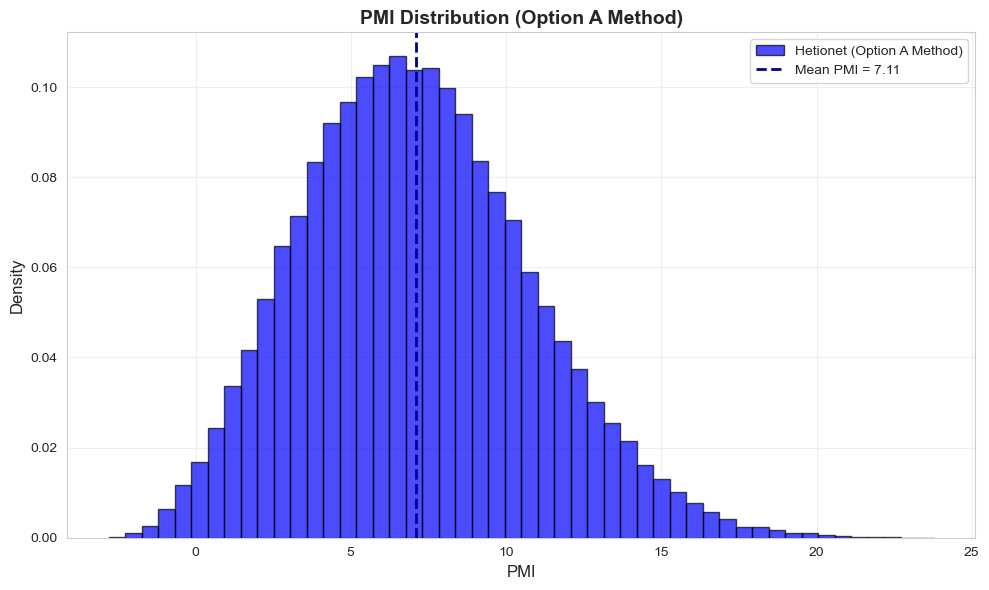

Saved PMI distribution to: /Users/lucas/Library/CloudStorage/OneDrive-TheUniversityofColoradoDenver/Repositories/Context-Aware-Path-Probability/results/option_a_pmi_distribution.png
Mean PMI: 7.1126
Median PMI: 6.9128
Std PMI: 3.6824


In [6]:
# PMI density histogram
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

ax.hist(hetionet_results['pmi'], bins=50, alpha=0.7,
        label='Hetionet (Option A Method)', color='blue',
        density=True, edgecolor='black')

# Add mean line
mean_pmi = hetionet_results['pmi'].mean()
ax.axvline(mean_pmi, color='darkblue', linestyle='--',
           linewidth=2, label=f'Mean PMI = {mean_pmi:.2f}')

ax.set_xlabel('PMI', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('PMI Distribution (Option A Method)',
             fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(results_dir / 'option_a_pmi_distribution.png',
            dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved PMI distribution to: {results_dir / 'option_a_pmi_distribution.png'}")
print(f"Mean PMI: {mean_pmi:.4f}")
print(f"Median PMI: {hetionet_results['pmi'].median():.4f}")
print(f"Std PMI: {hetionet_results['pmi'].std():.4f}")

## Degree-Stratified Scatter Plots

Visualize how node degrees affect compositional predictions.
All probabilities remain ≤ 1.0 (no invalid regions).


Degree product statistics:
  Endpoints only: 2 - 258192
  Total connectivity: 3e+01 - 8e+62
  Joint connectivity: 3e+01 - 2e+89


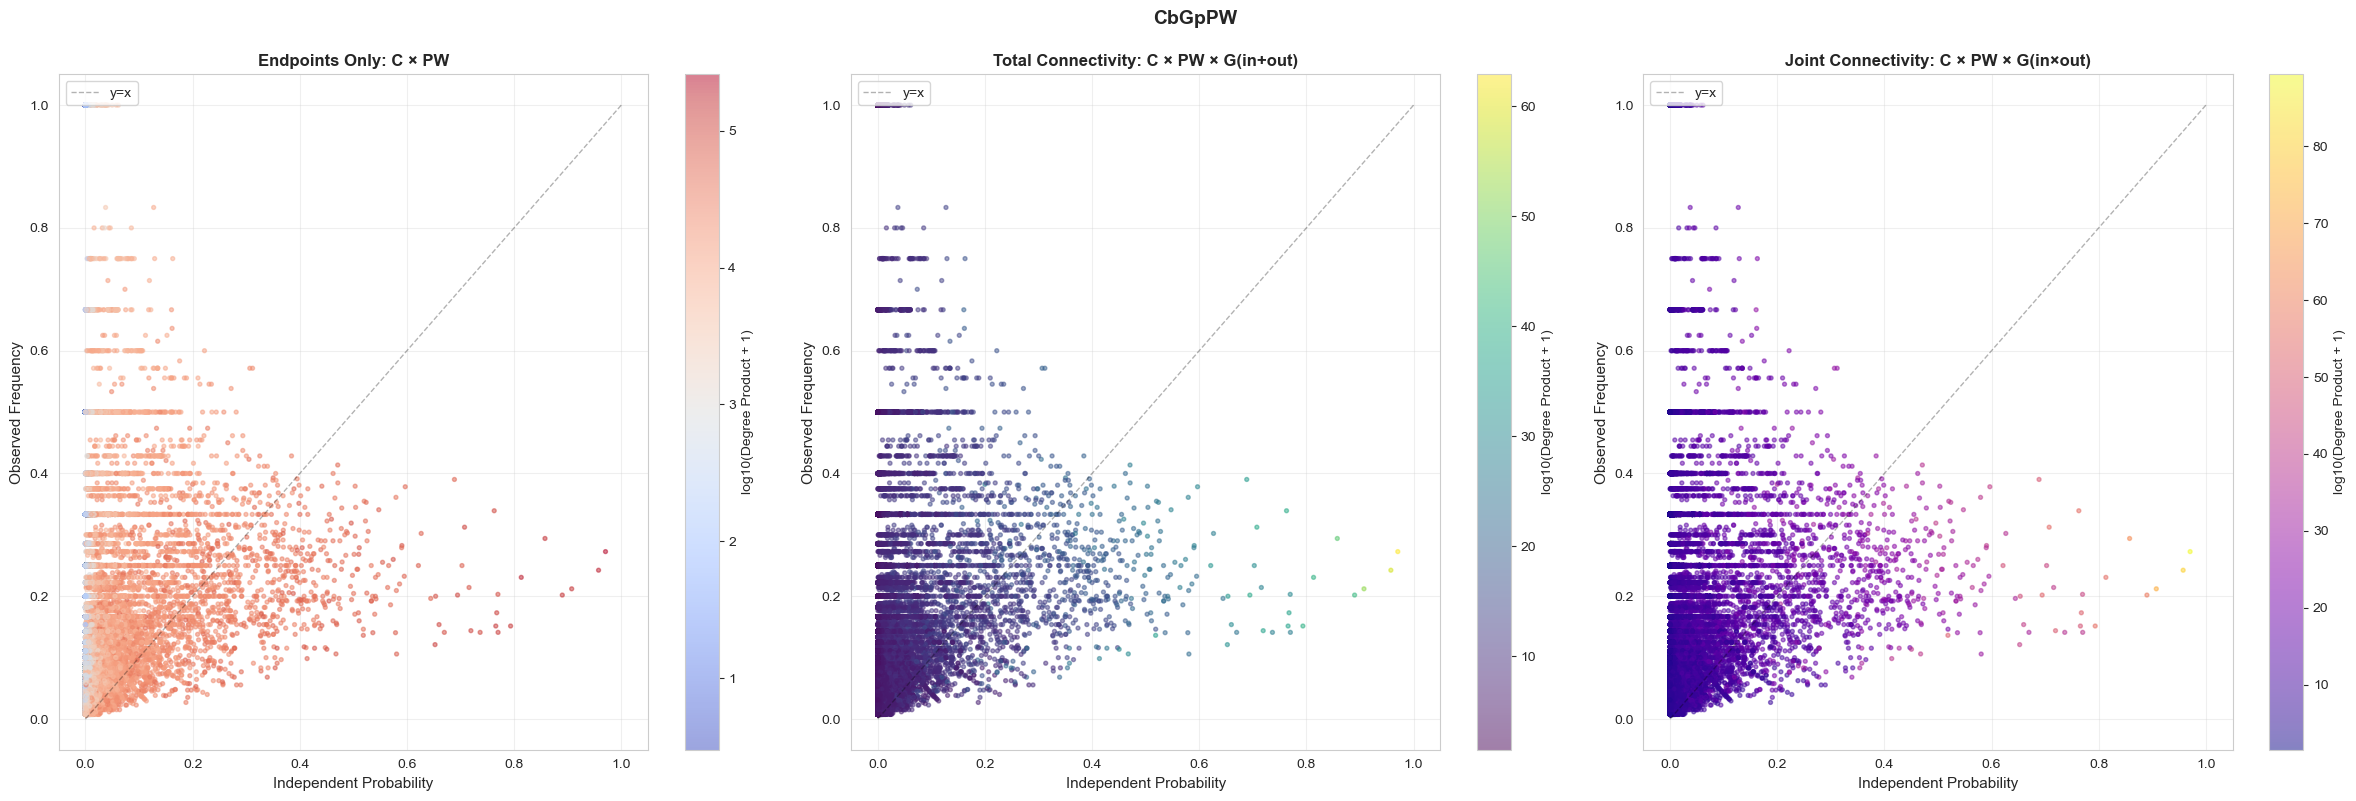


Saved degree product comparison to: /Users/lucas/Library/CloudStorage/OneDrive-TheUniversityofColoradoDenver/Repositories/Context-Aware-Path-Probability/results/cbgpw_degree_product_comparison.png


In [18]:
# Compute three degree product formulations
hetionet_results['degree_product_endpoints'] = (
    hetionet_results['compound_degree'] * 
    hetionet_results['pathway_degree']
)

hetionet_results['degree_product_total'] = (
    hetionet_results['compound_degree'] * 
    hetionet_results['pathway_degree'] * 
    hetionet_results['pathway_degree_product_total']
)

hetionet_results['degree_product_joint'] = (
    hetionet_results['compound_degree'] * 
    hetionet_results['pathway_degree'] * 
    hetionet_results['pathway_degree_product_joint']
)

print(f"\nDegree product statistics:")
print(f"  Endpoints only: {hetionet_results['degree_product_endpoints'].min():.0f} - {hetionet_results['degree_product_endpoints'].max():.0f}")
print(f"  Total connectivity: {hetionet_results['degree_product_total'].min():.0e} - {hetionet_results['degree_product_total'].max():.0e}")
print(f"  Joint connectivity: {hetionet_results['degree_product_joint'].min():.0e} - {hetionet_results['degree_product_joint'].max():.0e}")

# Create 1×3 grid of scatter plots comparing degree products
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# Plot 1: Endpoints only (C × PW)
ax = axes[0]
scatter = ax.scatter(
    hetionet_results['compositional_prob'],
    hetionet_results['observed_freq'],
    c=np.log10(hetionet_results['degree_product_endpoints'] + 1),
    cmap='coolwarm', alpha=0.5, s=1
)
scatter.set_sizes([8])
plt.colorbar(scatter, ax=ax, label='log10(Degree Product + 1)')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=1, label='y=x')
ax.set_xlabel('Independent Probability', fontsize=11)
ax.set_ylabel('Observed Frequency', fontsize=11)
ax.set_title('Endpoints Only: C × PW', fontsize=12, fontweight='bold')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

# Plot 2: Total connectivity (C × PW × ∏(in + out))
ax = axes[1]
scatter = ax.scatter(
    hetionet_results['compositional_prob'],
    hetionet_results['observed_freq'],
    c=np.log10(hetionet_results['degree_product_total'] + 1),
    cmap='viridis', alpha=0.5, s=1
)
scatter.set_sizes([8])
plt.colorbar(scatter, ax=ax, label='log10(Degree Product + 1)')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=1, label='y=x')
ax.set_xlabel('Independent Probability', fontsize=11)
ax.set_ylabel('Observed Frequency', fontsize=11)
ax.set_title('Total Connectivity: C × PW × G(in+out)', fontsize=12, fontweight='bold')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

# Plot 3: Joint connectivity (C × PW × ∏(in × out))
ax = axes[2]
scatter = ax.scatter(
    hetionet_results['compositional_prob'],
    hetionet_results['observed_freq'],
    c=np.log10(hetionet_results['degree_product_joint'] + 1),
    cmap='plasma', alpha=0.5, s=1
)
scatter.set_sizes([8])
plt.colorbar(scatter, ax=ax, label='log10(Degree Product + 1)')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=1, label='y=x')
ax.set_xlabel('Independent Probability', fontsize=11)
ax.set_ylabel('Observed Frequency', fontsize=11)
ax.set_title('Joint Connectivity: C × PW × G(in×out)', fontsize=12, fontweight='bold')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.suptitle('CbGpPW',
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(results_dir / 'cbgpw_degree_product_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nSaved degree product comparison to: {results_dir / 'cbgpw_degree_product_comparison.png'}")

## Save Results

In [8]:
# Save results with Option A suffix
hetionet_results.to_csv(results_dir / f'metapath_{metapath_name}_hetionet_OPTION_A.csv',
                        index=False)

print(f"Results saved to:")
print(f"  {results_dir / f'metapath_{metapath_name}_hetionet_OPTION_A.csv'}")
print(f"\nAll {len(hetionet_results)} probabilities are mathematically valid (≤ 1.0)")
print(f"Compare with notebook 11.1 (old broken method)")

Results saved to:
  /Users/lucas/Library/CloudStorage/OneDrive-TheUniversityofColoradoDenver/Repositories/Context-Aware-Path-Probability/results/metapath_CbGpPW_hetionet_OPTION_A.csv

All 122728 probabilities are mathematically valid (≤ 1.0)
Compare with notebook 11.1 (old broken method)


## Conclusions

**Mathematical Validity Confirmed:**
- All compositional probabilities ≤ 1.0
- Option A probabilistic combination is mathematically sound
- Biologically realistic (multiple pathways = redundancy, not additivity)

**Formula:**
- `P = 1 - ∏(1 - P_individual)` treats genes as independent alternative routes
- Automatically enforces upper bound of 1.0

**Degree Dependencies:**
- Scatter plots reveal how compound degree, pathway degree, and their product affect predictions
- Can guide future model improvements

**Comparison:**
- Notebook 11.1 (old): Probabilities up to ~3.2 (invalid)
- This notebook (corrected): All probabilities ≤ 1.0 (valid)

**Reference:**
Himmelstein et al. (2017) Systematic integration of biomedical knowledge prioritizes drugs for repurposing. eLife.